# Final Evaluation & Backtesting

*Companion notebook — the scripts in `src/` are the source of truth; this notebook loads and displays their outputs.*

In [1]:
import os, sys, warnings; warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('..')); os.environ['TF_CPP_MIN_LOG_LEVEL']='3'
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
from config import *


## 1. Walk-forward validation table (model selection)

In [2]:
cv = pd.read_csv(os.path.join(RESULTS_DIR, 'cv_results.csv'))
cv.sort_values(['asset','RMSE_ret_mean']).round(5)

,asset,model,n_folds,RMSE_ret_mean,RMSE_ret_std,MAE_ret_mean,MAE_ret_std,R2_ret_mean,R2_ret_std,RMSE_usd_mean,RMSE_usd_std,DirAcc_pct_mean,DirAcc_pct_std
6,Bitcoin,CatBoost,4,0.03156,0.00695,0.02136,0.00415,-0.00131,0.00570,1427.06617,434.17045,50.21478,2.31601
5,Bitcoin,LightGBM,4,0.03158,0.00692,0.02140,0.00420,-0.00344,0.00412,1430.51610,432.69011,51.15979,1.73690
0,Bitcoin,Naive,4,0.03160,0.00690,0.02130,0.00415,-0.00480,0.00339,1429.07651,434.50095,0.00000,0.00000
4,Bitcoin,RandomForest,4,0.03160,0.00688,0.02140,0.00416,-0.00536,0.00555,1432.90172,433.81705,49.95704,2.40051
3,Bitcoin,Ridge,4,0.03161,0.00693,0.02135,0.00414,-0.00507,0.00283,1430.33747,435.81126,49.35567,1.89929
1,Bitcoin,Naive-Mean,4,0.03163,0.00694,0.02133,0.00418,-0.00662,0.00353,1430.94798,435.03942,48.79725,1.61640
2,Bitcoin,ARIMA,4,0.03164,0.00695,0.02135,0.00422,-0.00699,0.00424,1431.80039,436.62336,48.10997,2.39319
7,Bitcoin,GRU,4,0.03168,0.00697,0.02136,0.00418,-0.00897,0.00479,1432.61201,435.63222,49.39863,0.98329
8,Bitcoin,LSTM,4,0.03170,0.00697,0.02142,0.00424,-0.01027,0.00503,1433.09348,436.33228,48.79725,0.70844
14,Gold,LightGBM,4,0.01112,0.00223,0.00788,0.00127,-0.00241,0.00491,28.40946,16.83060,52.60336,2.22139


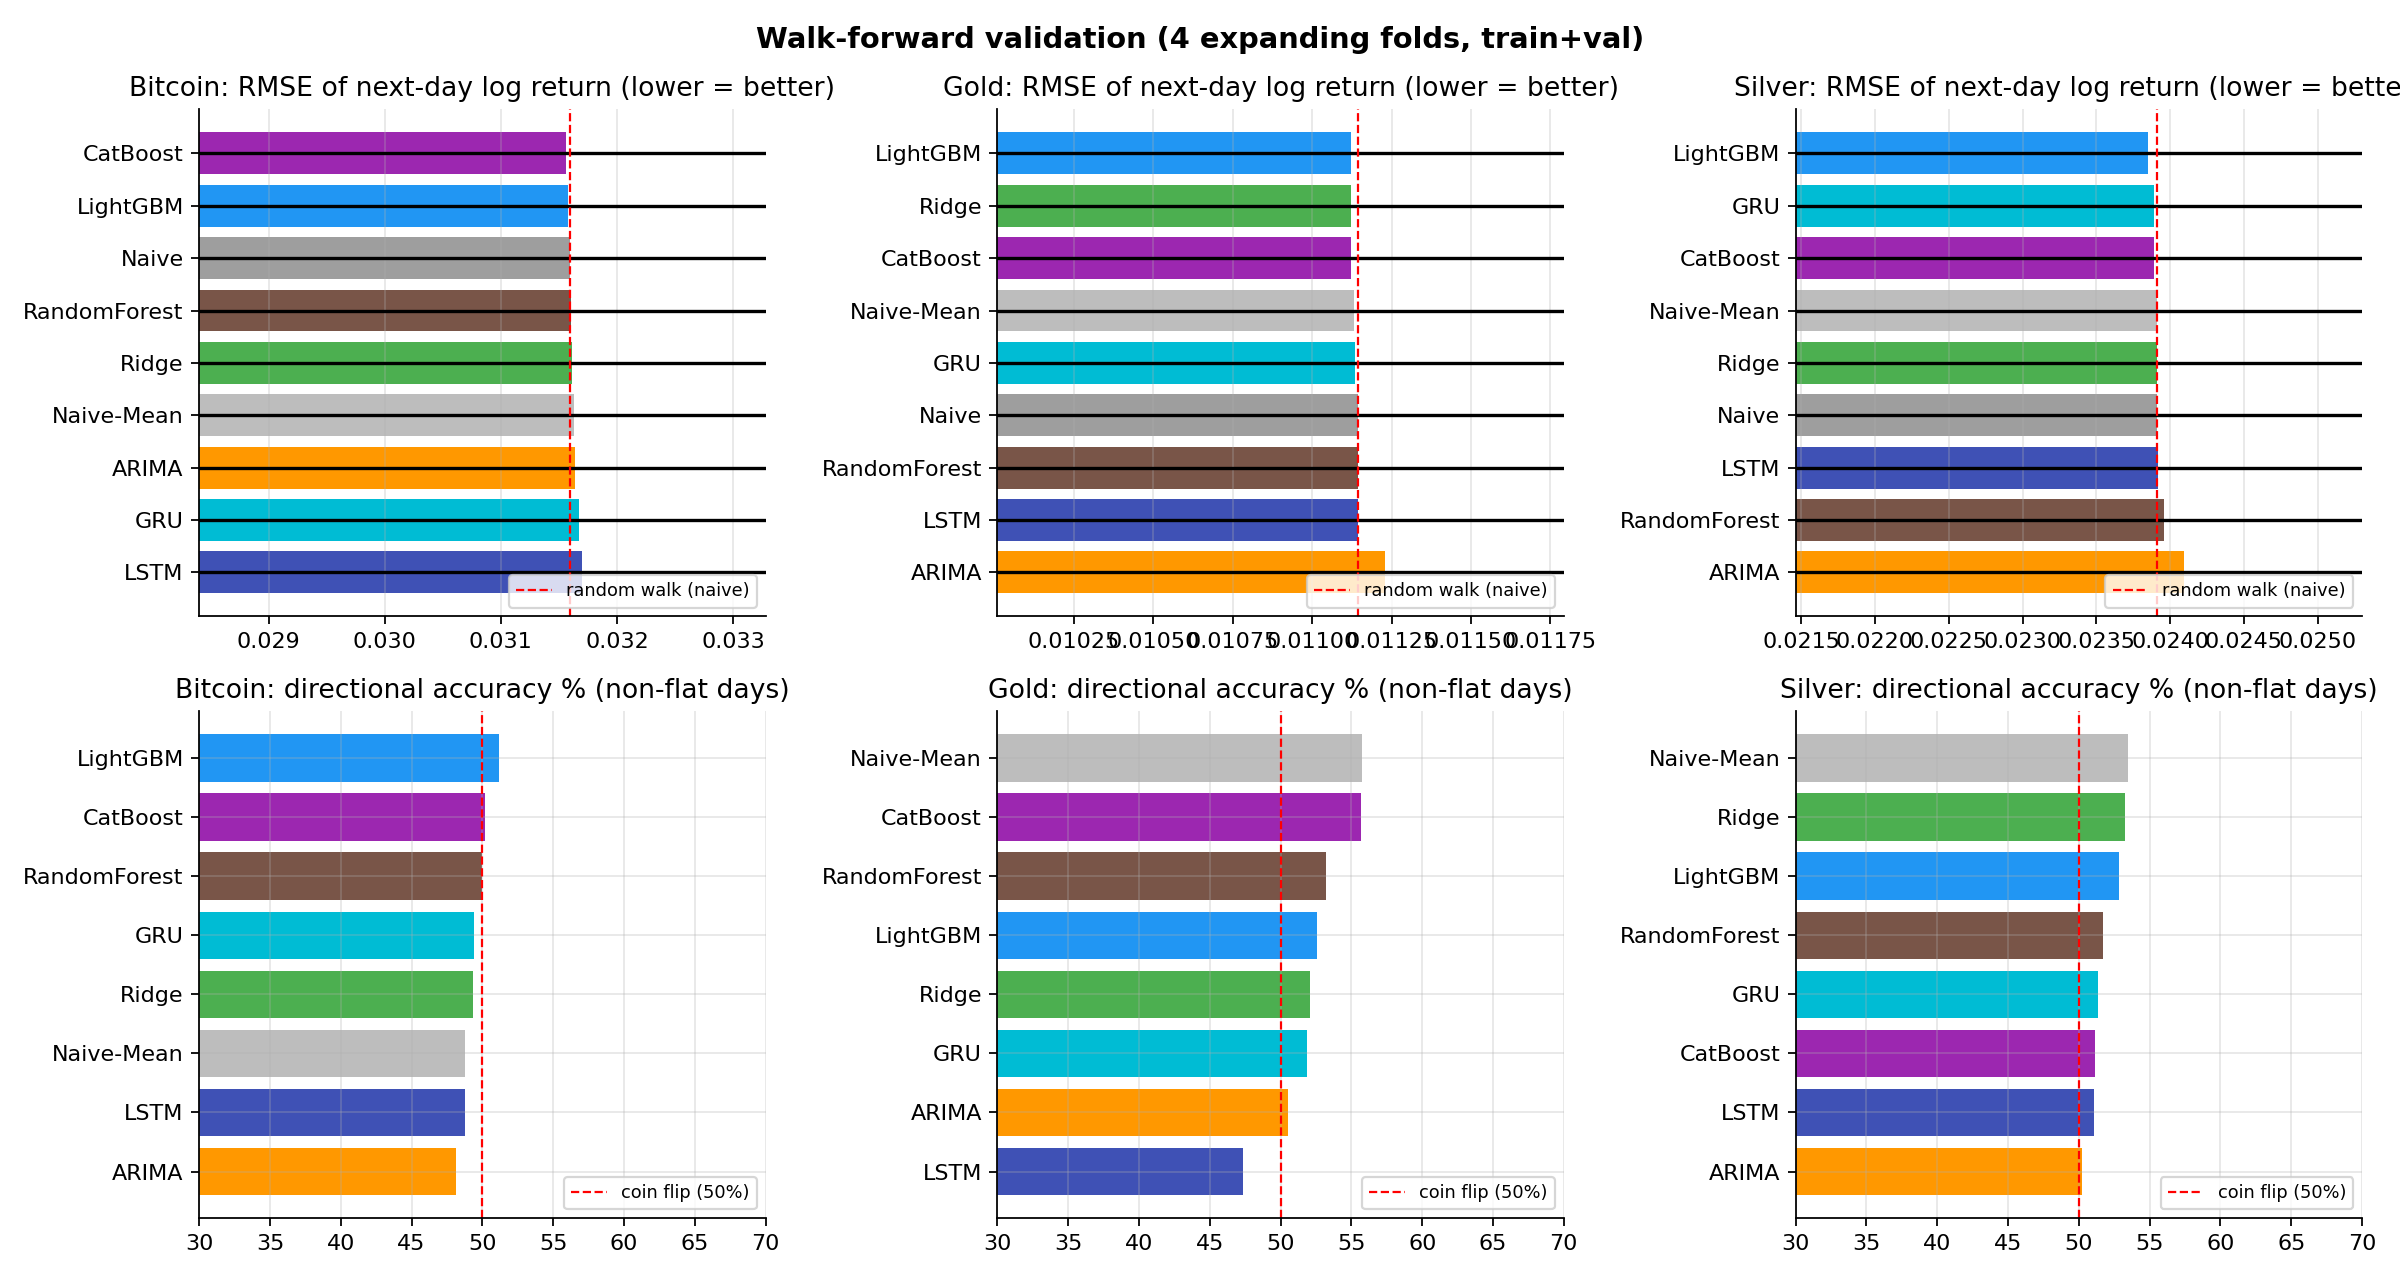

In [3]:
display(Image(os.path.join(FIGURES_DIR, 'model_comparison_cv.png')))

## 2. Untouched test set — evaluated once

In [4]:
te = pd.read_csv(os.path.join(RESULTS_DIR, 'final_test_results.csv'))
te[['asset','model','MAE_usd','RMSE_usd','MAPE_usd','RMSE_ret','R2_ret','DirAcc_pct','DirAcc_pvalue','DM_pvalue','strategy_return_pct','buy_hold_return_pct']].sort_values(['asset','RMSE_ret']).round(4)

,asset,model,MAE_usd,RMSE_usd,MAPE_usd,RMSE_ret,R2_ret,DirAcc_pct,DirAcc_pvalue,DM_pvalue,strategy_return_pct,buy_hold_return_pct
9,Bitcoin,Stacked,1061.3424,1442.9437,1.5174,0.0206,0.0133,50.2415,0.5000,0.4390,2.3419,14.4856
5,Bitcoin,LightGBM,1076.4874,1446.1825,1.5386,0.0207,0.0097,51.2077,0.3905,0.7926,5.4165,14.4856
4,Bitcoin,RandomForest,1064.4789,1448.8089,1.5223,0.0207,0.0037,48.3092,0.7109,0.6174,-3.5795,14.4856
1,Bitcoin,Naive-Mean,1067.3204,1451.3804,1.5265,0.0208,-0.0000,49.2754,0.6095,0.8140,14.3712,14.4856
0,Bitcoin,Naive,1066.4235,1451.7352,1.5243,0.0208,-0.0010,0.0000,1.0000,NaN,0.0000,14.4856
3,Bitcoin,Ridge,1071.9730,1452.5905,1.5317,0.0208,-0.0018,47.8261,0.7564,0.9128,4.4225,14.4856
8,Bitcoin,LSTM,1068.0633,1453.4449,1.5263,0.0208,-0.0035,46.3768,0.8670,0.3533,-7.8130,14.4856
6,Bitcoin,CatBoost,1071.0766,1453.7623,1.5318,0.0208,-0.0036,46.8599,0.8347,0.7374,-5.6199,14.4856
7,Bitcoin,GRU,1075.8596,1458.3086,1.5365,0.0209,-0.0099,46.8599,0.8347,0.3522,-14.0184,14.4856
2,Bitcoin,ARIMA,1067.9616,1459.4390,1.5282,0.0209,-0.0123,46.8599,0.8347,0.3480,-8.9782,14.4856


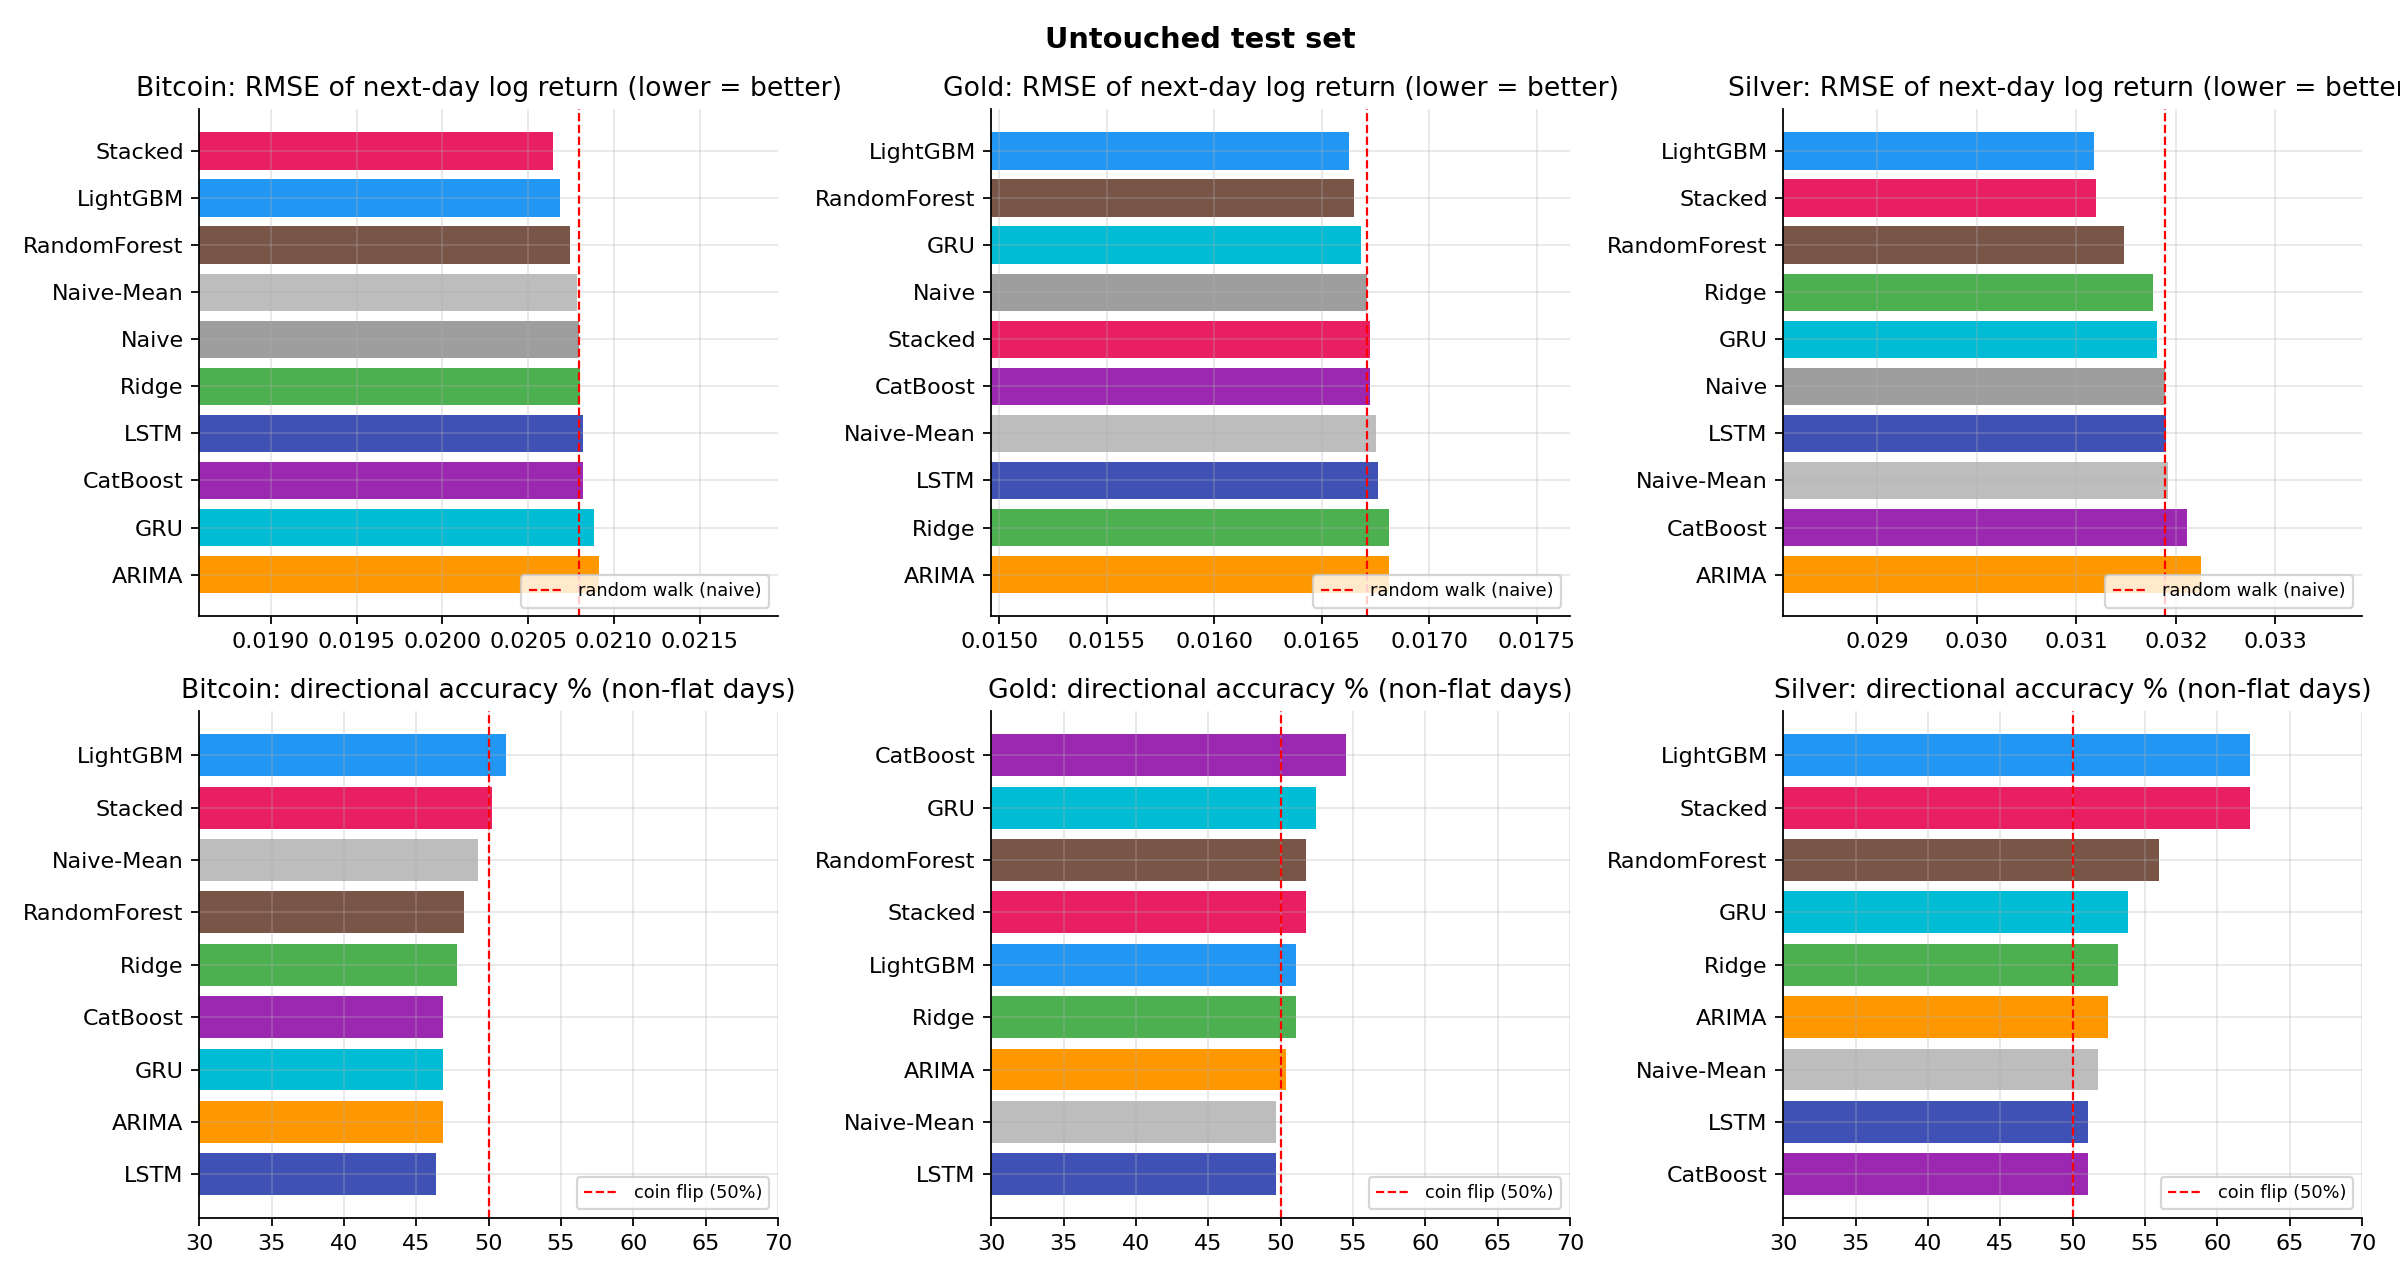

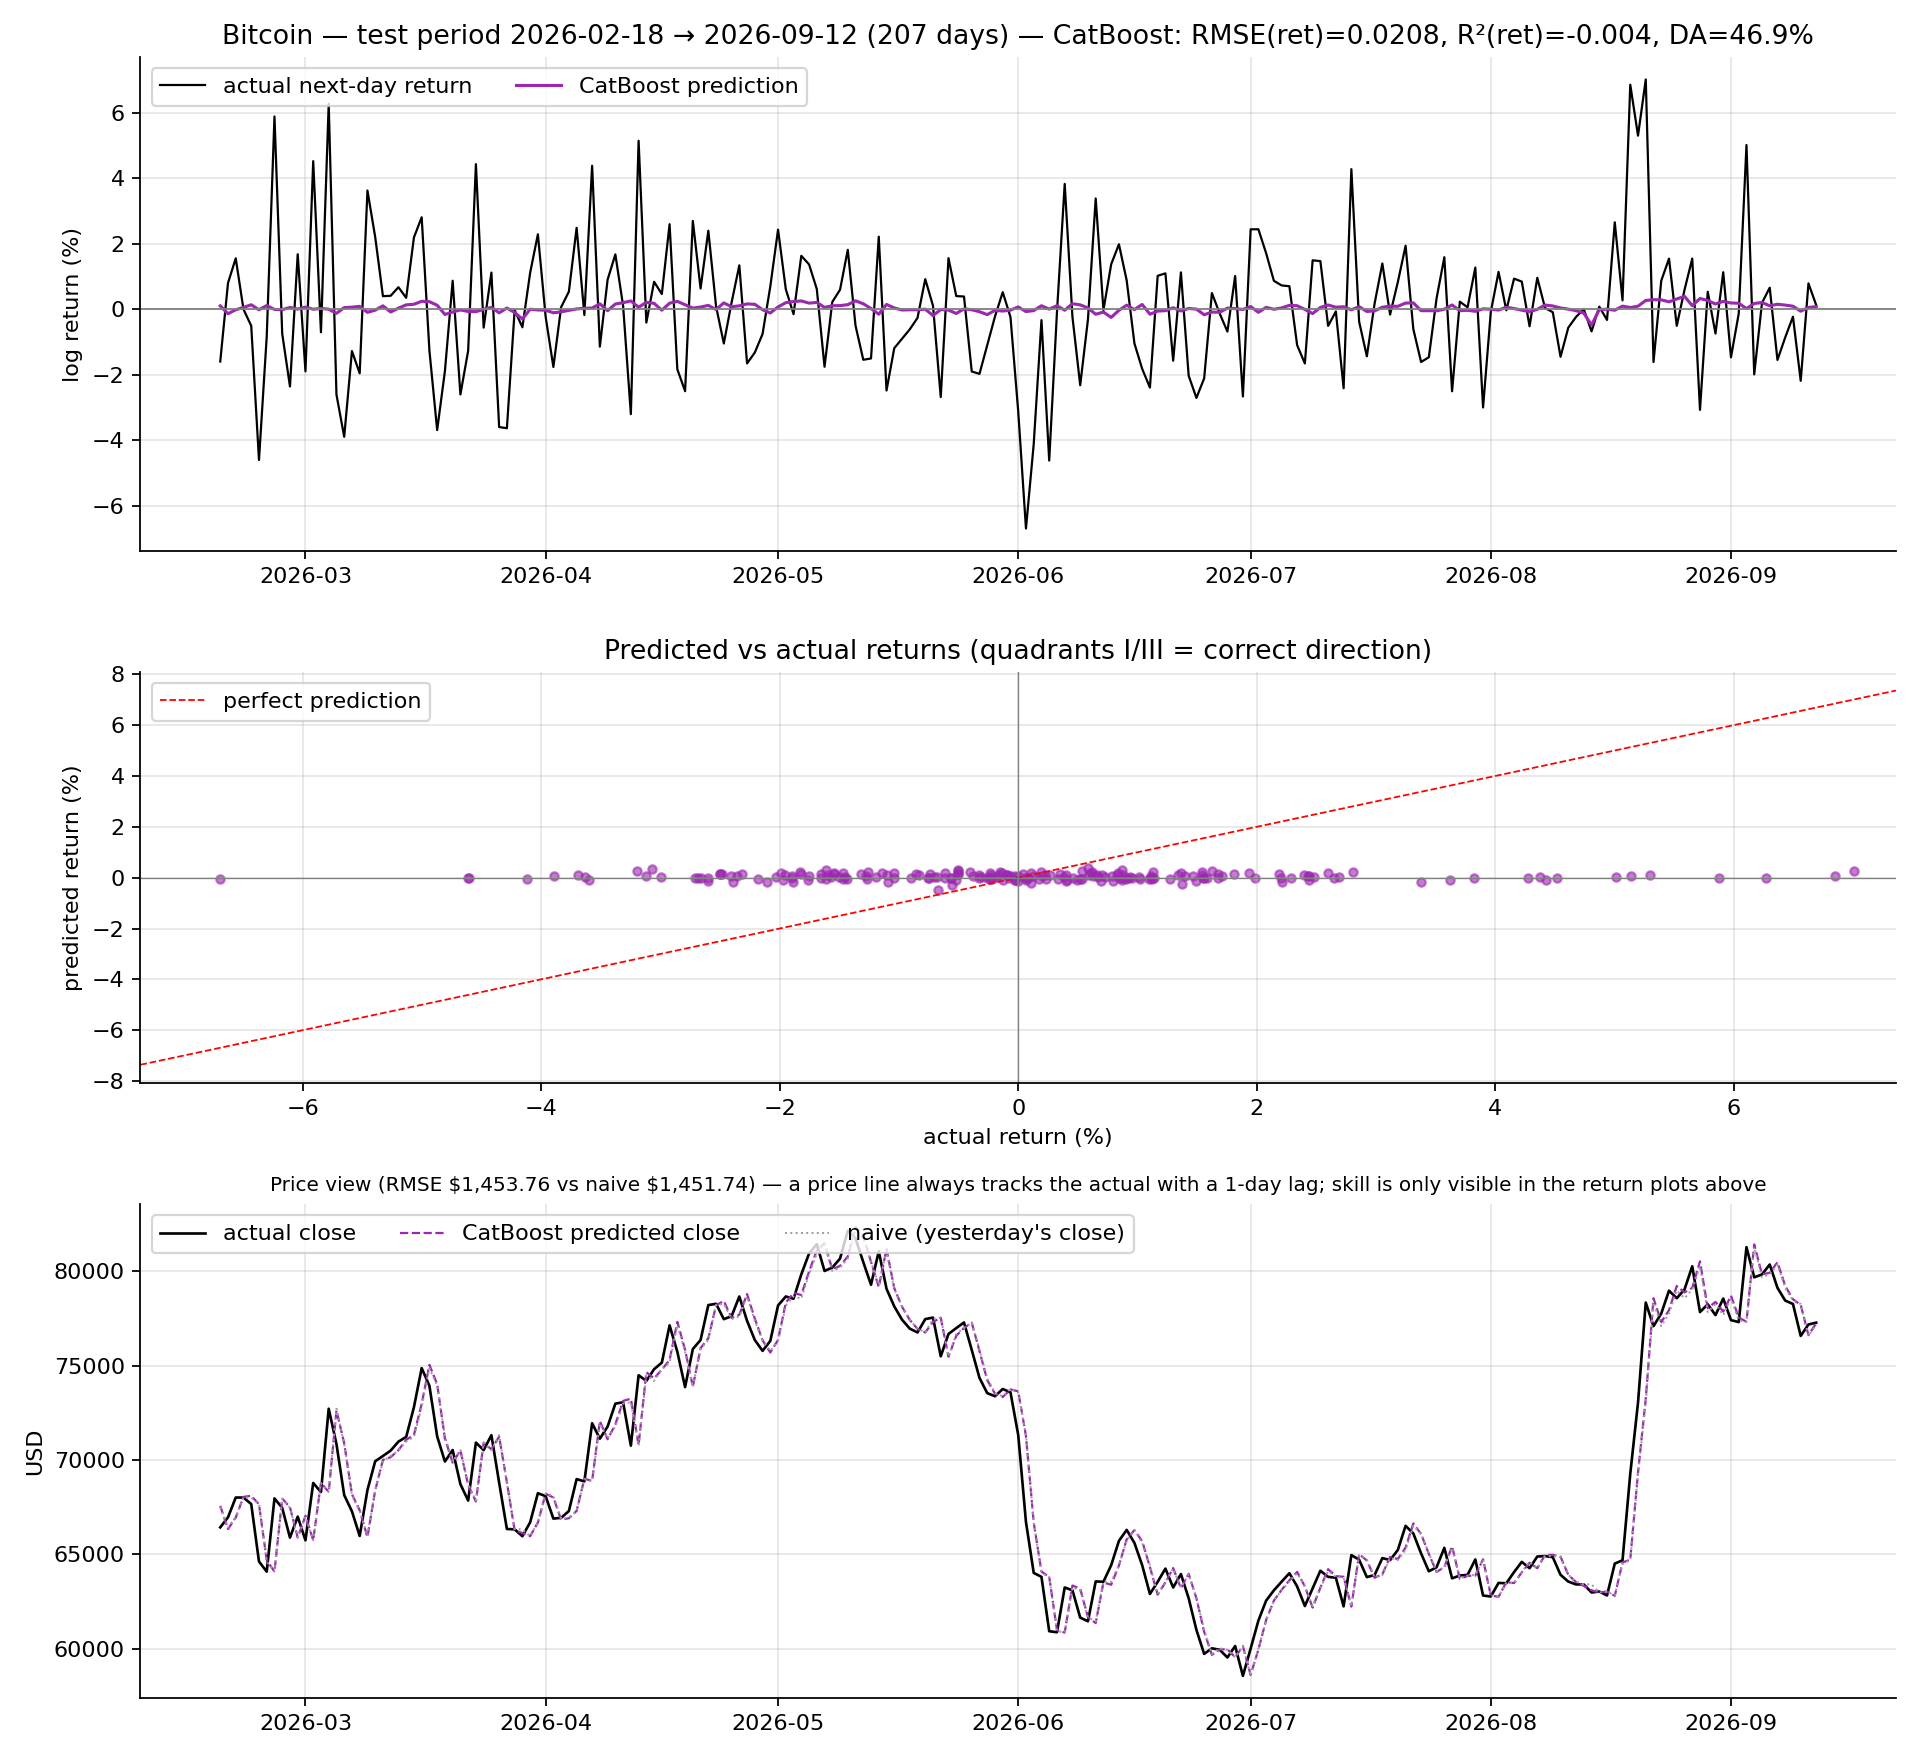

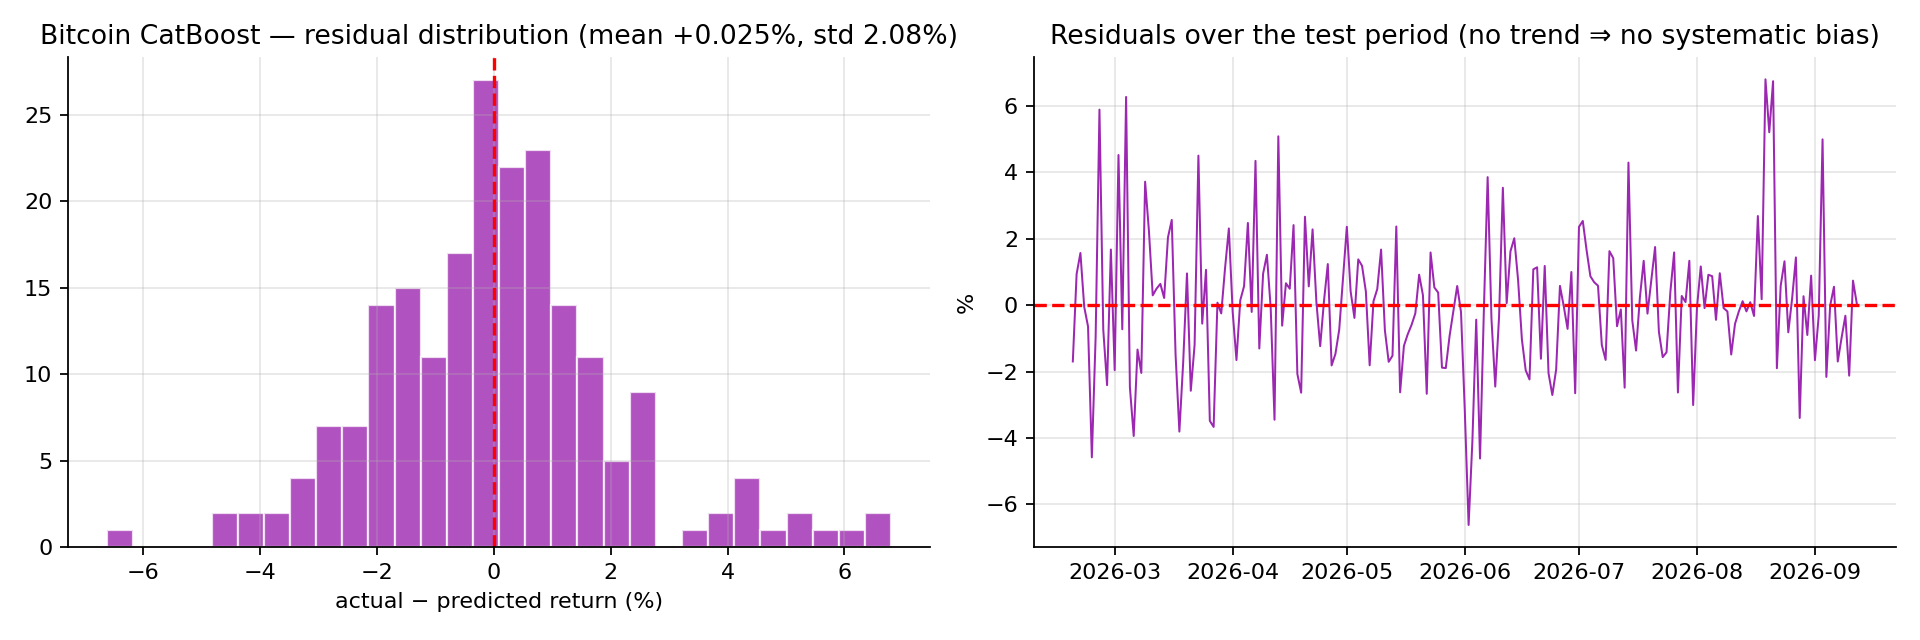

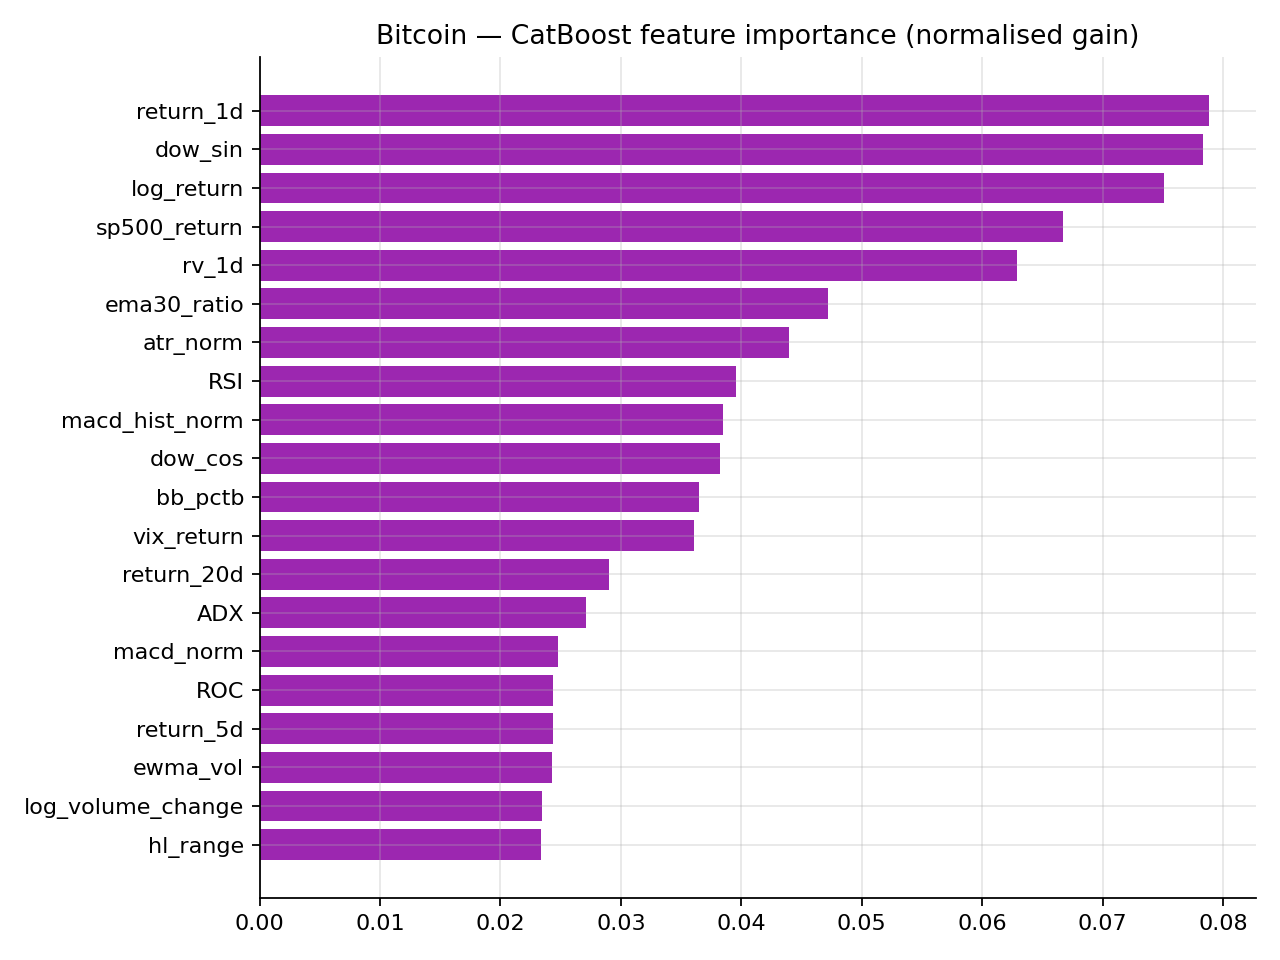

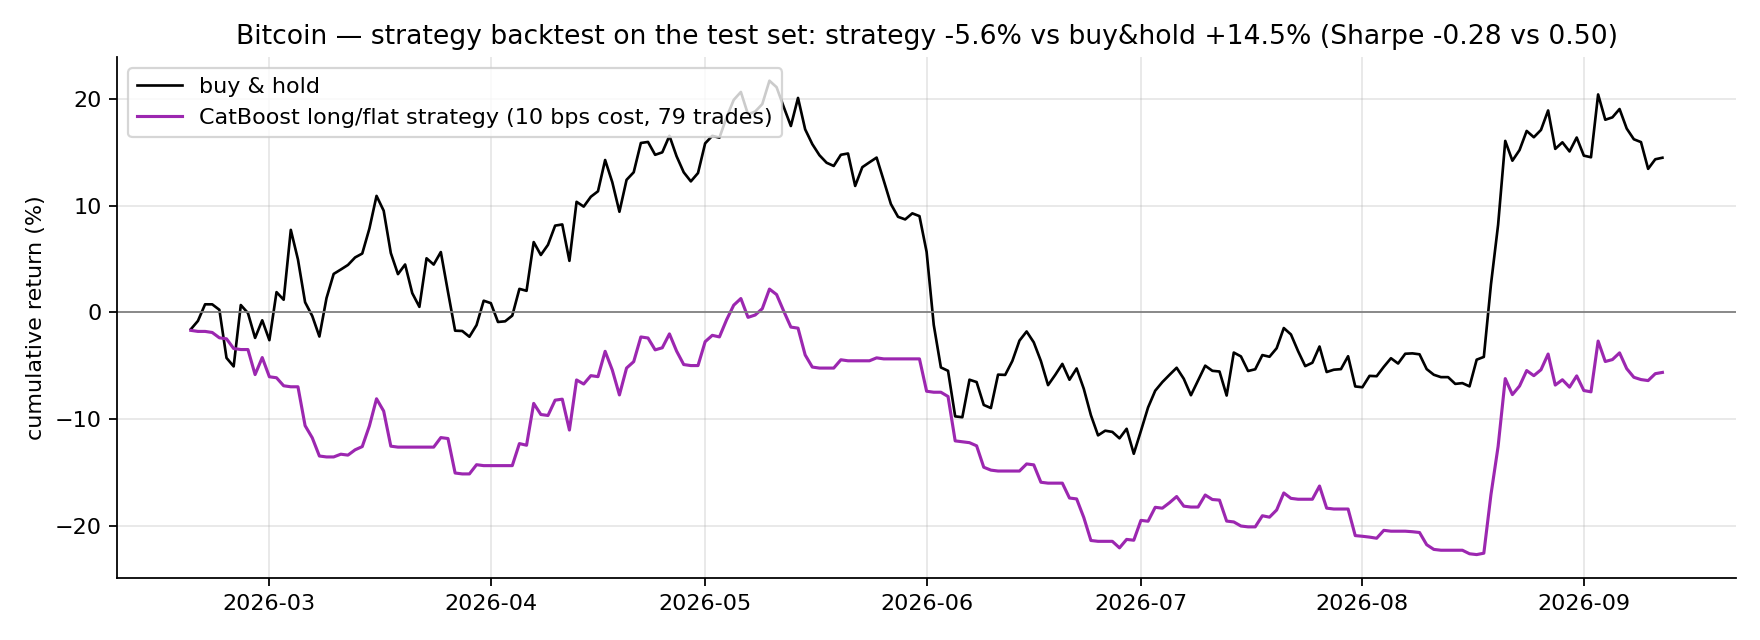

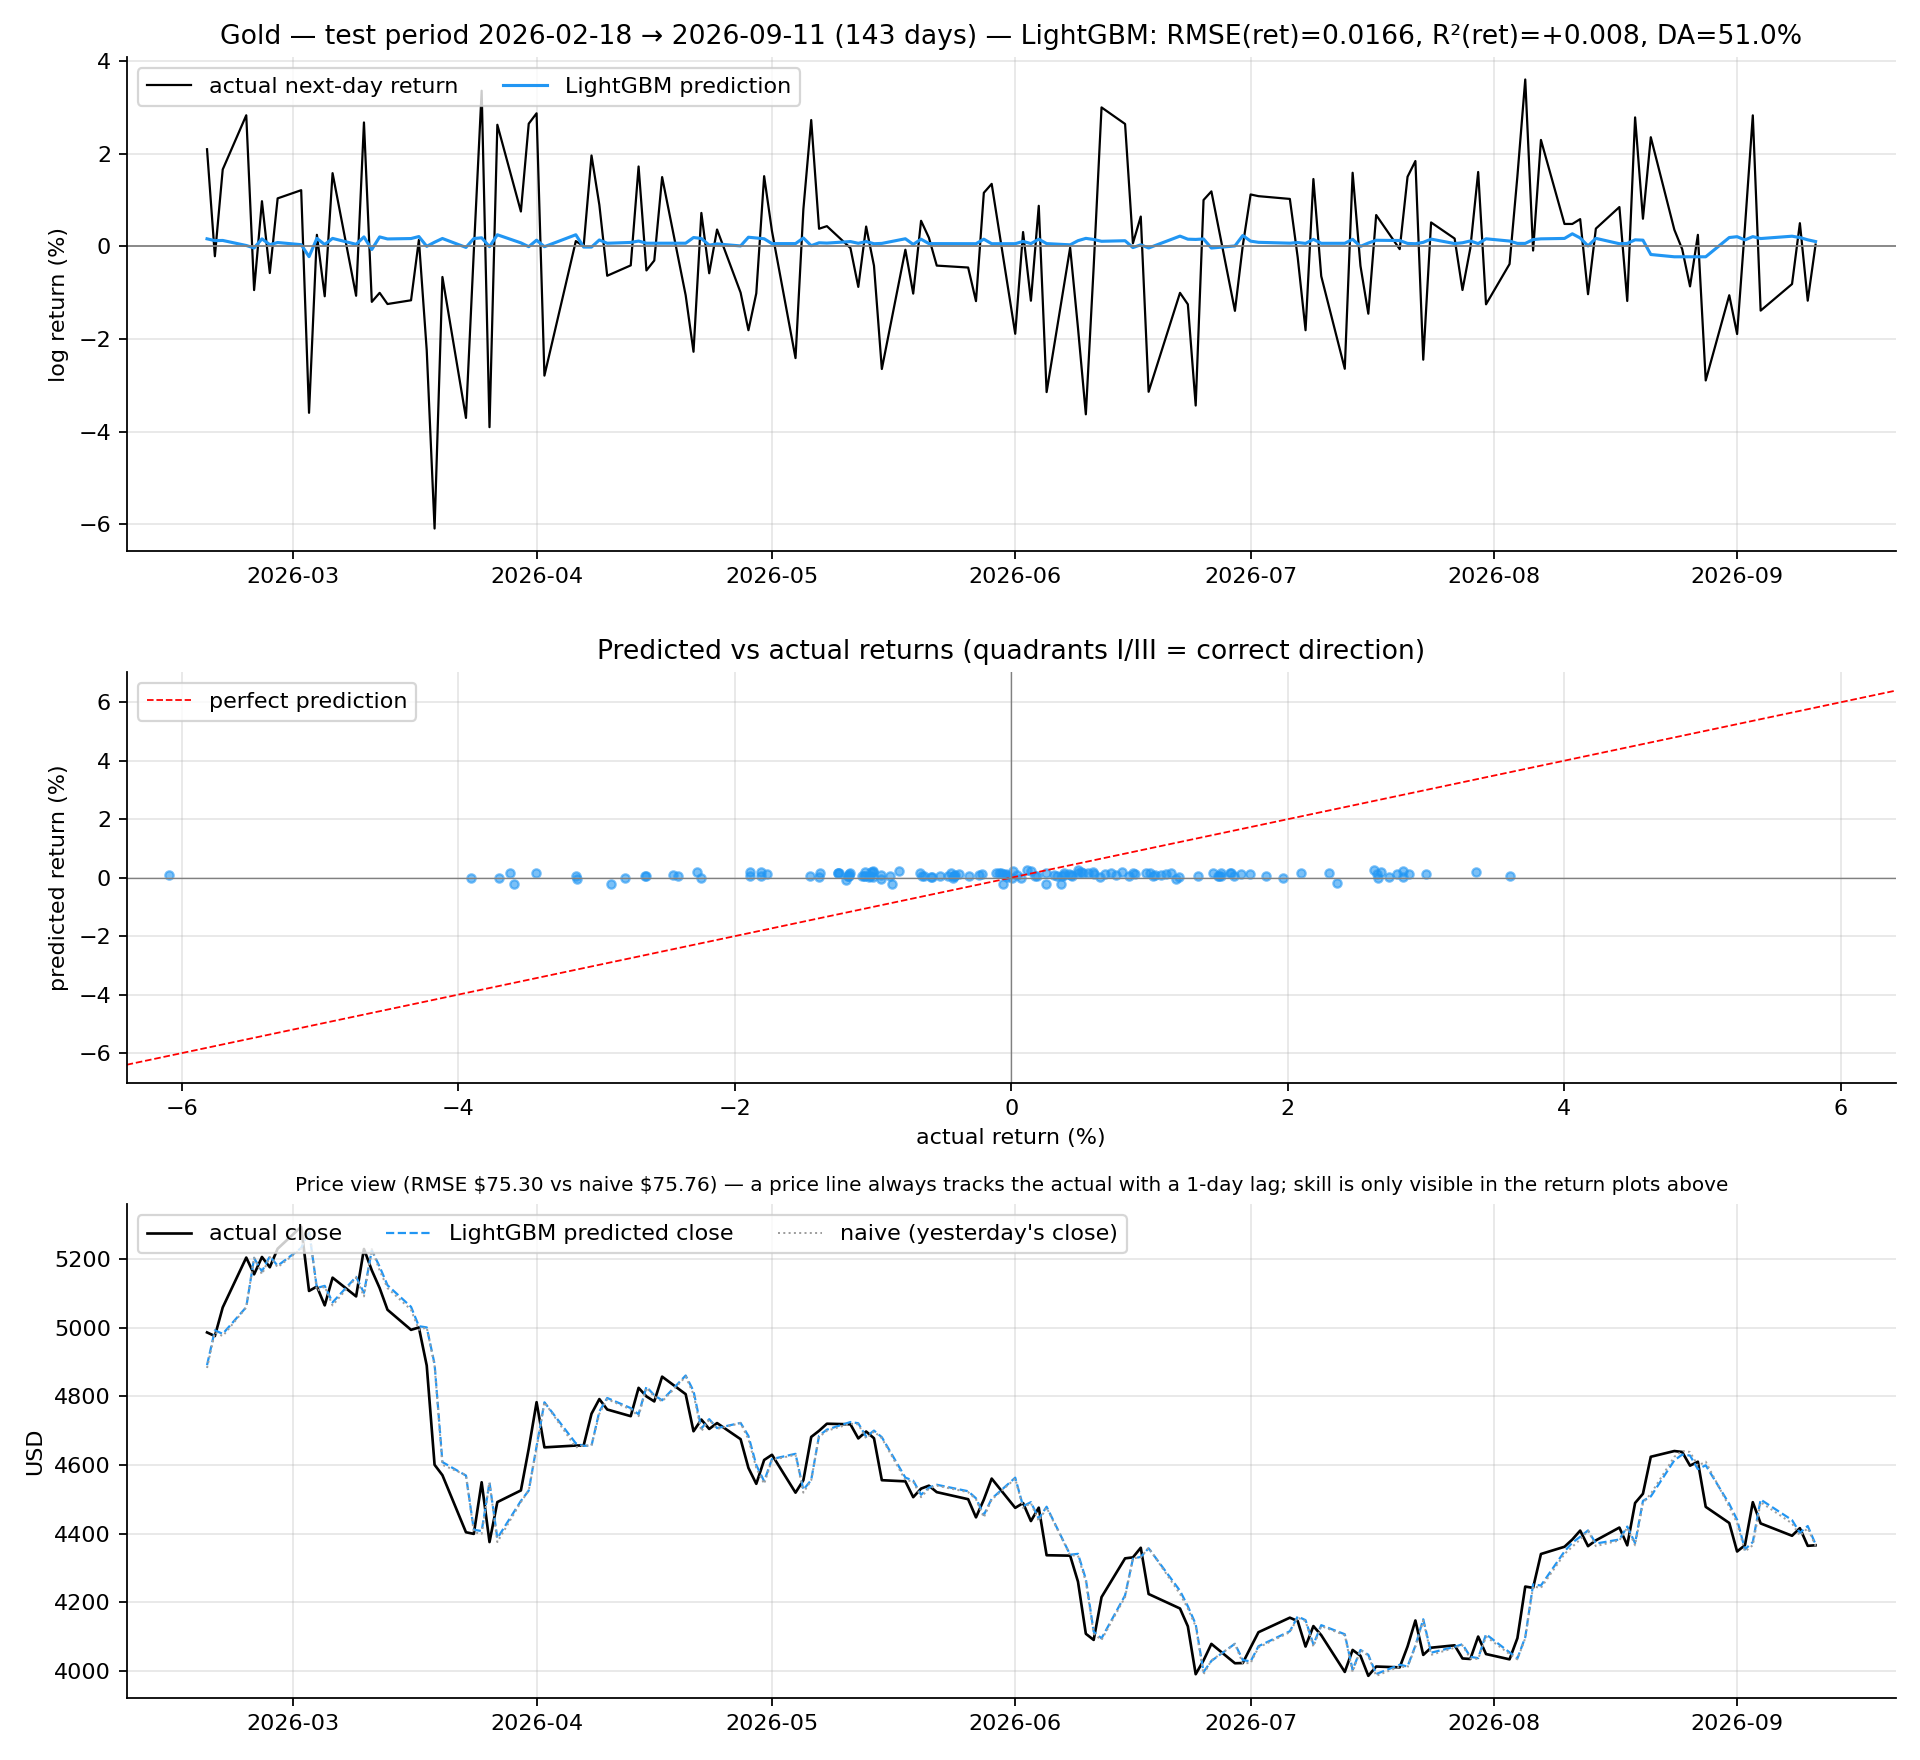

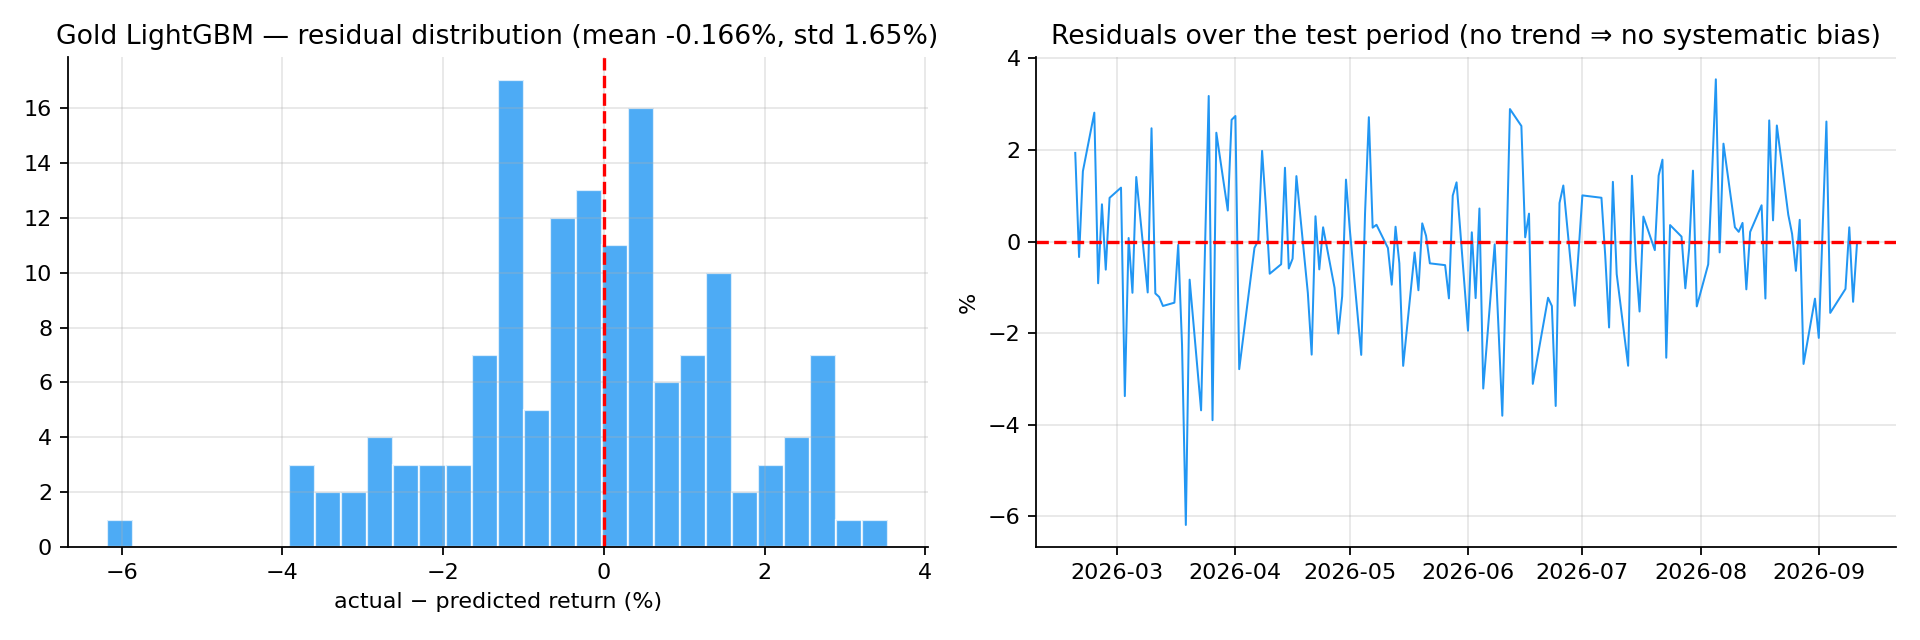

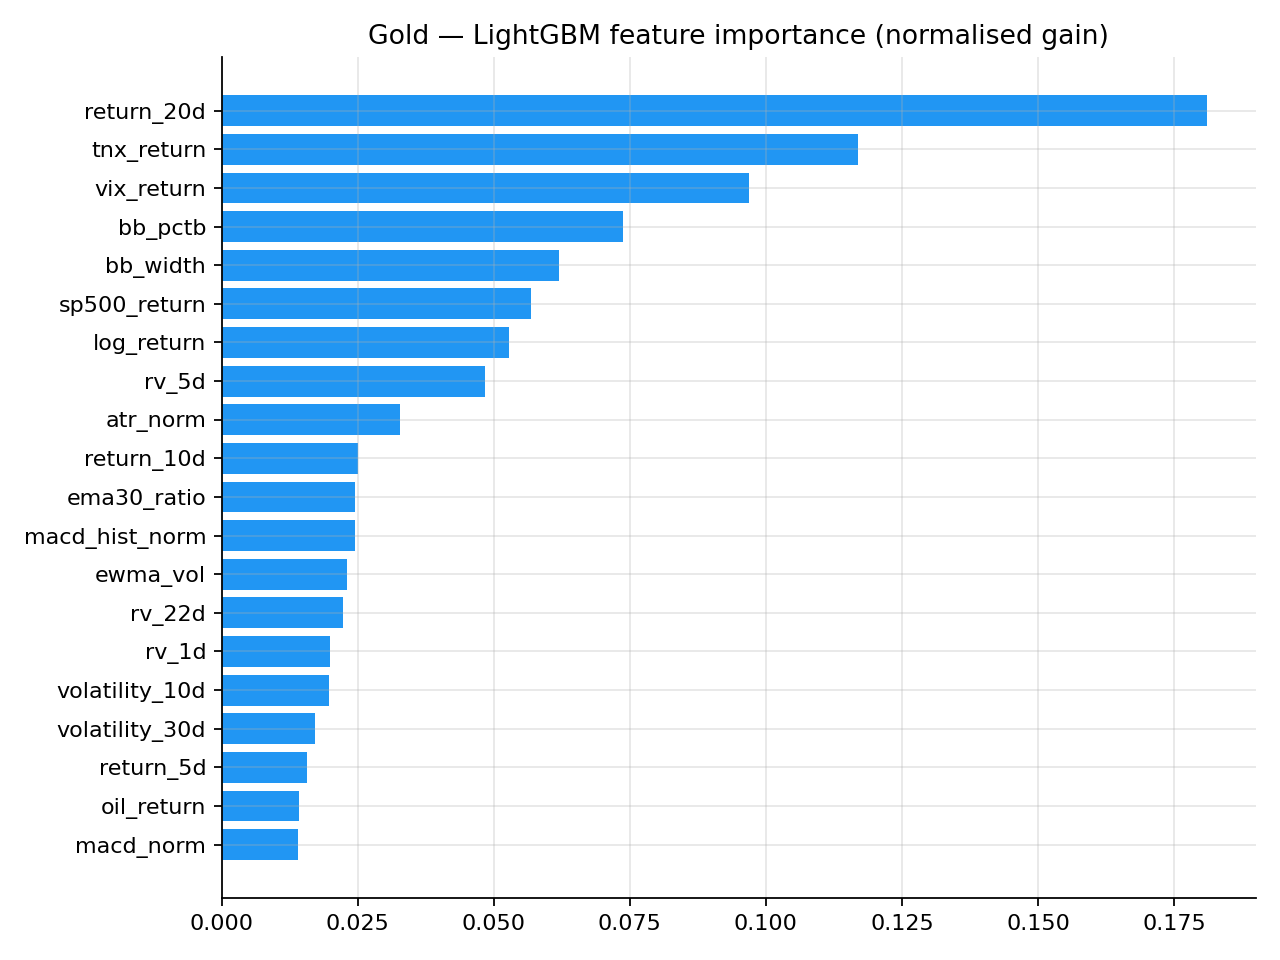

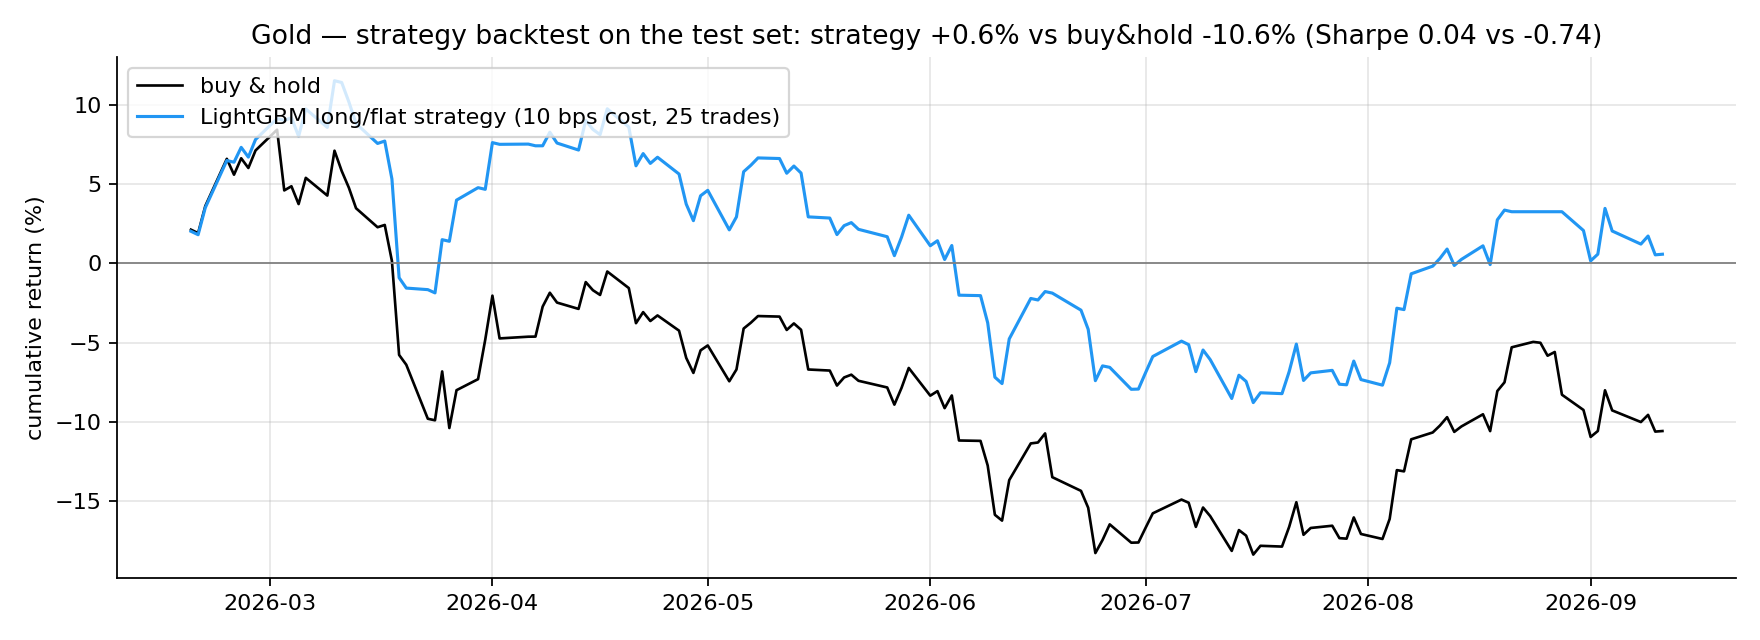

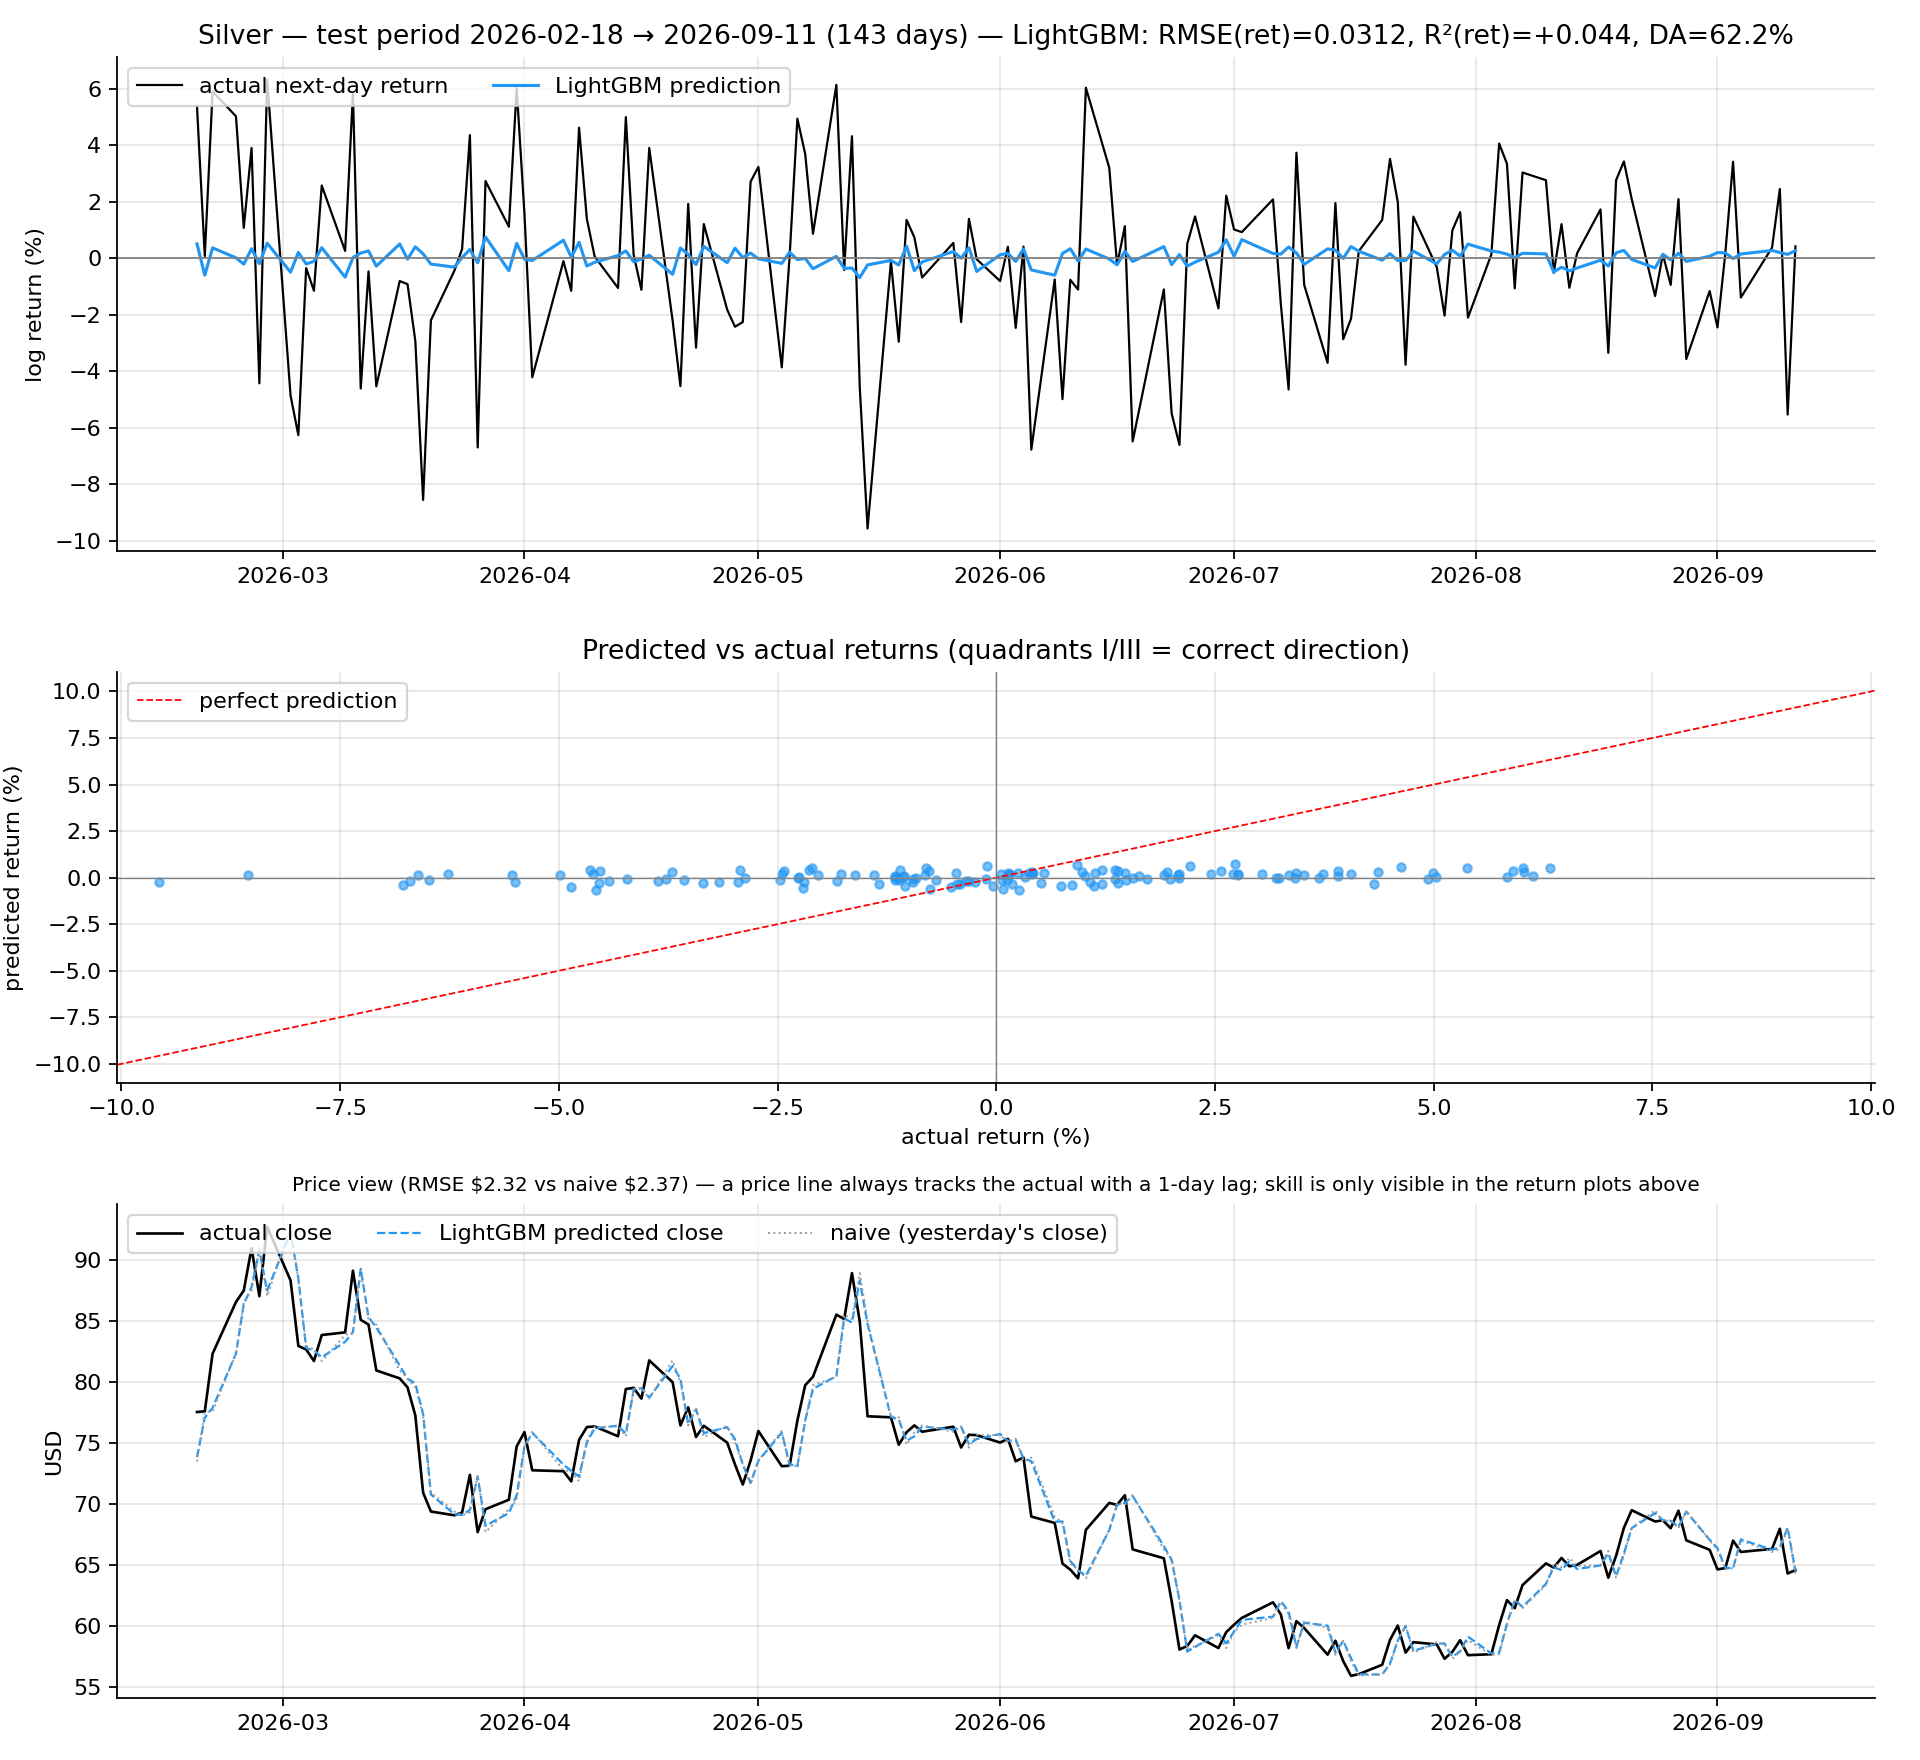

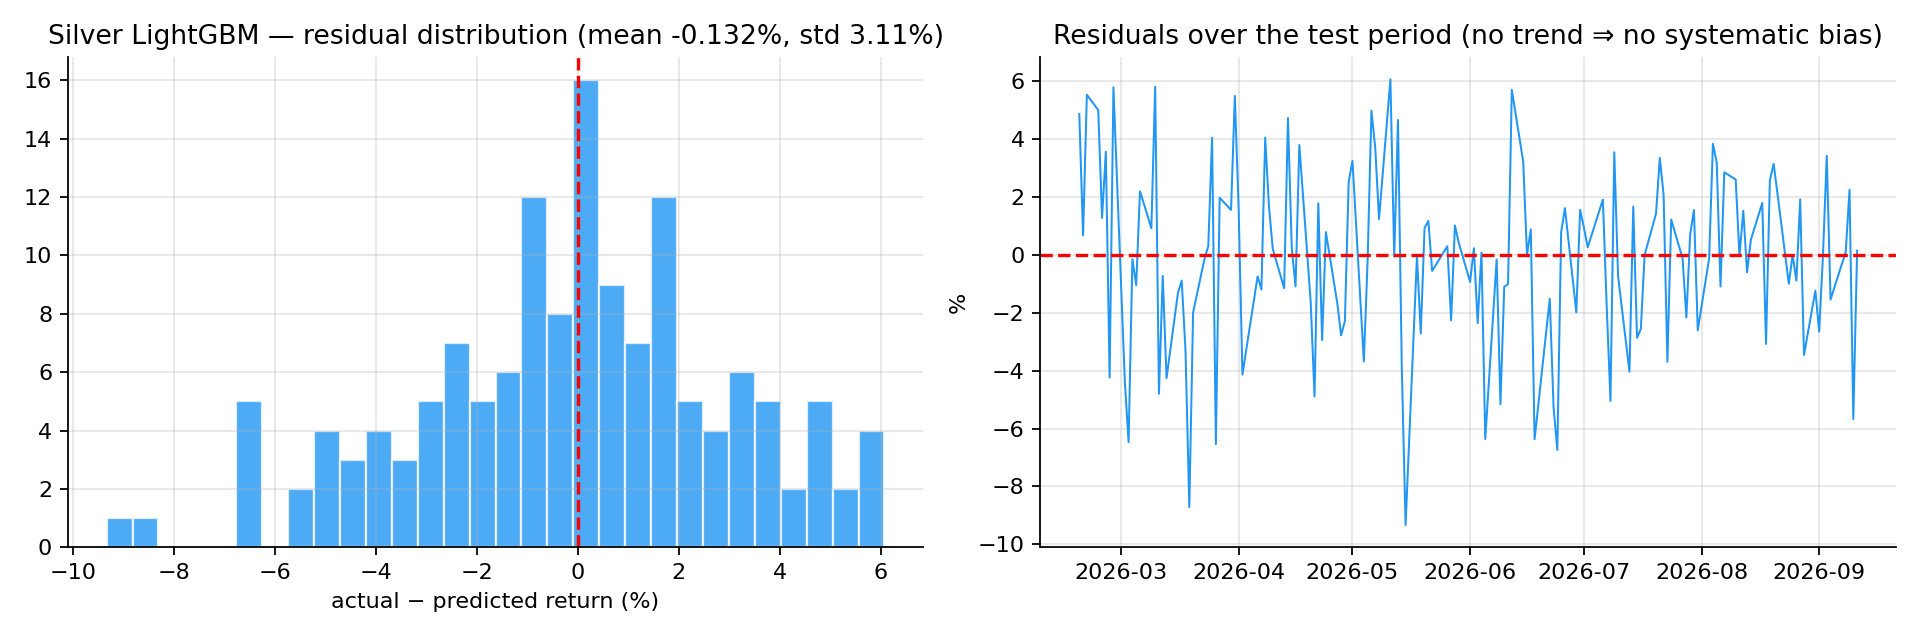

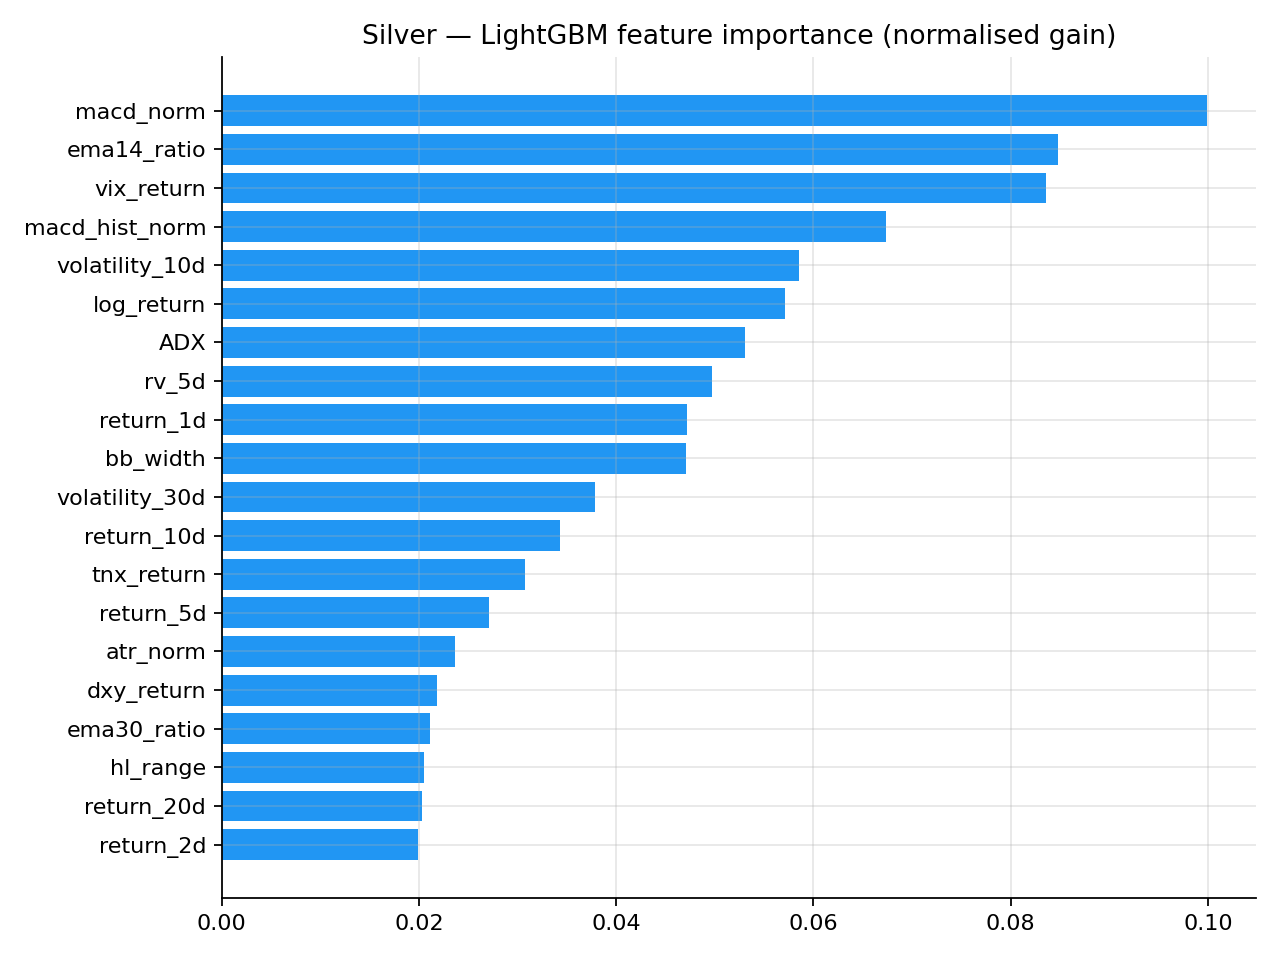

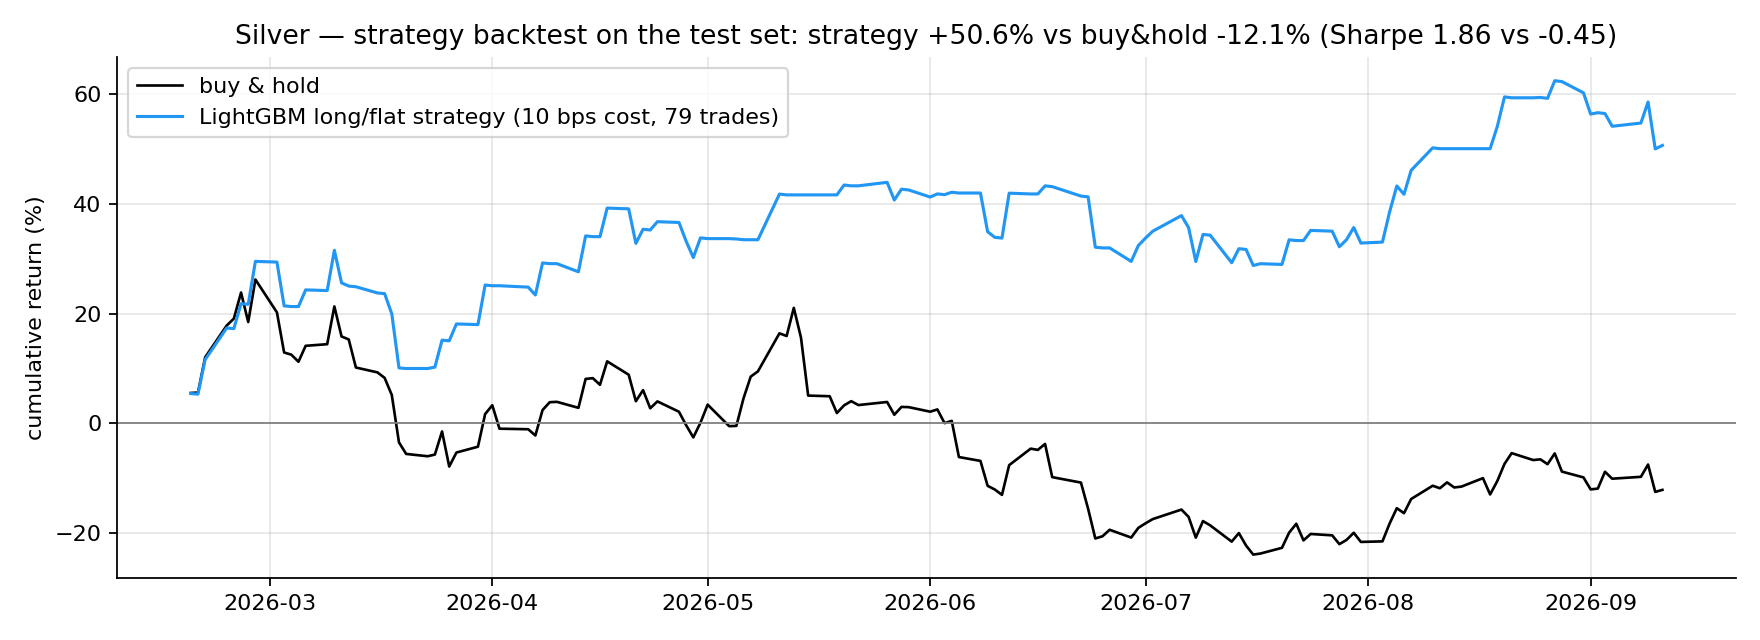

In [5]:
display(Image(os.path.join(FIGURES_DIR, 'model_comparison_test.png')))
for a in ASSETS:
    for s in ['actual_vs_predicted','residuals','feature_importance','strategy']:
        p = os.path.join(FIGURES_DIR, f'{get_prefix(a)}_{s}.png')
        if os.path.exists(p): display(Image(p))

## 3. Served model per asset

In [6]:
import json; s = json.load(open(MODEL_STATUS_PATH))
for a, v in s.items(): print(a, '→', v['primary_model'], '| CV RMSE', round(v['cv_rmse_ret'],5), 'vs naive', round(v['cv_rmse_ret_naive'],5))

Bitcoin → CatBoost | CV RMSE 0.03156 vs naive 0.0316
Gold → LightGBM | CV RMSE 0.01112 vs naive 0.01114
Silver → LightGBM | CV RMSE 0.02385 vs naive 0.02391


## 4. Conclusions
See `results/FINAL_RESULTS.md` and `docs/RESULTS.md` for the written interpretation.